# DEG analysis - SlideTags dataset (Striatum)

Mirrors `NucSeq_XDP/DEG/NucSeq_DEG_factors.ipynb`, adapted for
`all_lib_adata_zoned_ct-cured_aligned.h5ad`. Differences from that notebook:

- **Single tissue** (Striatum only) - no `TISSUE` branching needed.
- **Condition levels** are `"healthy"`/`"diseased"` (not `Control`/`XDP`), and only **9 donors**
  total: **2 healthy** (SCF-22-057, SCF-23-068) vs **7 diseased**. Healthy vs diseased
  contrasts therefore have only 2 donors on the healthy side - see the warning printed before
  that section.
- **No `cohort` column**, and **`sex` is 100% male** across all 9 donors (zero variance) - so
  neither is usable as a covariate here.
- A **fourth `TYPE_DEG` option**, `"r_nebula"`, is added (via a one-line change to
  `utils/nebula_with_factors.py`): it uses the *real*, spatially-measured dorsal-ventral
  coordinate `r` (fit from Slide-tags x/y positions via splines), instead of the
  gene-expression-derived `gradient_score` proxy used in the NucSeq notebook. `r` is only
  available for donors that have a fitted spline file and for cells with spatial data
  (`has_spatial=True`) - see the "Spatial position r" section, where you choose which donors
  enter that specific analysis.
- Two **independent, self-contained "Run" sections** at the bottom, matching how the NucSeq
  notebook lays out "Run for all ct" vs "Run for all Zones" as separate blocks you run
  selectively:
  1. **Healthy vs diseased, per cell type** (loops every `ct_for_deg` category)
  2. **Cell type vs cell type** (any two `ct_for_deg` categories, optionally restricted to one
     condition, or pooled with `condition` added as a covariate)

Both Run sections share one `TYPE_DEG` (set once below) and both automatically pick up
whichever extra covariate that implies (`gradient_score`, `r`, PCs, or none) - `TYPE_DEG`
drives that internally in `nebula_with_factors.run_nebula_with_factors`, so it should **not**
be added by hand to `COVARIATES_FOR_DEG` (adding it manually creates a duplicate term in the
auxiliary factor-significance test).

In [ ]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
from scipy import sparse
import scanpy as sc
import matplotlib.pyplot as plt
import os
import glob
import rpy2.robjects as ro
import shutil
import seaborn as sns

from dotenv import load_dotenv; load_dotenv()

from utils import preprocessing
from utils import nebula_with_factors as nebula_utils

# ATTENTION: need for proper running in jupyter notebook
%matplotlib inline

PARALLEL_NEBULA_SCRIPT_PATH = os.getenv("PARALLEL_NEBULA_SCRIPT")

ADATA_PATH = "/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/all_lib_adata_zoned_ct-cured_aligned.h5ad"
# ATTENTION: single-tissue (Striatum) dataset -> no TISSUE if/elif needed here (unlike NucSeq_DEG_factors.ipynb)

# TYPE_DEG controls which extra covariate/factor is modeled alongside the main contrast:
#   "baseline_nebula"       -> no extra covariate
#   "PCA_nebula"             -> healthy(baseline)-derived PCs, projected onto the rest, as covariates
#   "gradient_score_nebula"  -> transcriptomic dorsal-ventral proxy score (works for ALL cells, incl. non-spatial ones)
#   "r_nebula"                -> REAL spatial dorsal-ventral position `r` from fitted splines
#                                (only cells/donors with spatial data + a fitted spline - see "Spatial position r" section)
TYPE_DEG = "PCA_nebula"

# name of cell type variable annotation to use in this analysis
CT_FOR_DEG_VARIABLE = "ct_for_deg"
# name of sample variable
SAMPLE_VARIABLE = "donor_id"
# variable to test if differentially expressed (healthy vs diseased contrast)
CONTRAST_VARIABLE = "condition"
CONTRAST_BASELINE = "healthy"
CONTRAST_STIM = "diseased"

# ATTENTION: unlike NucSeq_DEG_factors.ipynb, this dataset has no "cohort" column, and "sex" is
# 100% male across all 9 donors (zero variance) -> neither can be used as a covariate here
COVARIATES_FOR_DEG = ["age_at_death", "pct_counts_mt", "pct_intronic"] # maybe batch???

# library size col for nebula
LIBRARY_SIZE_COL = "total_counts"

# Save folder
DEG_FOLDER = f"/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/DEG/{TYPE_DEG}"
os.makedirs(DEG_FOLDER, exist_ok=True)
DEG_FOLDER

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


'/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/DEG/PCA_nebula'

# Read adata

In [ ]:
print("Loading adata...")
adata = sc.read_h5ad(ADATA_PATH)
print(adata.obs.columns)

###########################
#ATTENTION: use gene names for DEG
adata.var.index = adata.var["gene_symbol"].astype(str)
adata.var.index.name = None  # avoid index-name/column-name collision once make_unique() changes some values below
adata.var_names_make_unique()  # 18 gene_symbol values are duplicated (e.g. SPATA13, ELFN2) - dedupe or var-name indexing breaks
###########################

###########################
#ATTENTION: `condition` has a dirty "diseased " (trailing-space) level that exactly overlaps
# with the cells that have no donor_id (114,692 unassigned demux-leftover cells) -> strip it
adata.obs["condition"] = adata.obs["condition"].astype(str).str.strip()
###########################

###########################
#ATTENTION: drop cells with no donor_id - can't fit the (1|donor) random effect for them, and
# they're exactly the dirty-condition leftover cells above (a whole extra "sample_09" pool
# that failed genotype demultiplexing)
n_before = adata.n_obs
adata = adata[adata.obs[SAMPLE_VARIABLE].notna()].copy()
print(f"Dropped {n_before - adata.n_obs} cells with no {SAMPLE_VARIABLE} (unassigned demux leftovers)")
###########################

###########################
#ATTENTION: remove "bad cell" types (same convention as NucSeq_DEG_factors.ipynb), including
# the literal "nan" string category (a real categorical level here, not a missing value)
mask_good_ct = (
    (~adata.obs[CT_FOR_DEG_VARIABLE].astype(str).str.startswith("-")) &
    (adata.obs[CT_FOR_DEG_VARIABLE].astype(str) != "nan")
)
adata = adata[mask_good_ct].copy()
###########################

###########################
#ATTENTION: be sure cell types have no space
adata.obs[CT_FOR_DEG_VARIABLE] = adata.obs[CT_FOR_DEG_VARIABLE].astype(str).str.replace(" ", "_")
###########################

print("\nDonors:")
print(adata.obs.drop_duplicates(SAMPLE_VARIABLE)[[SAMPLE_VARIABLE, "condition", "age_at_death", "sex"]].sort_values(SAMPLE_VARIABLE))
print("\nCell types:")
print(adata.obs[CT_FOR_DEG_VARIABLE].value_counts())

Loading adata...
Index(['x', 'y', 'pct_intronic', 'dbscan_clusters', 'dbscan_score',
       'has_spatial', 'sample', 'Neighborhood_name',
       'Neighborhood_bootstrapping_probability',
       'Neighborhood_aggregate_probability', 'Class_name',
       'Class_bootstrapping_probability', 'Class_aggregate_probability',
       'Subclass_name', 'Subclass_bootstrapping_probability',
       'Subclass_aggregate_probability', 'Group_name',
       'Group_bootstrapping_probability', 'Group_aggregate_probability',
       'Cluster_label', 'Cluster_name', 'Cluster_alias',
       'Cluster_bootstrapping_probability', 'n_genes_by_counts',
       'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts',
       'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt',
       'library_id', 'donor_number', 'donor_id', 'condition', 'sex',
       'age_at_onset', 'age_at_death', 'bcl', 'library', 'Sorted',
       'mapping_coupling_for_zoning', 'zone', 'zone_probability',
       'mapping_coupling_fo

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Dropped 114692 cells with no donor_id (unassigned demux leftovers)

Donors:
          donor_id condition  age_at_death   sex
1       SCF-18-003  diseased          41.0  male
405870  SCF-18-006  diseased          51.0  male
137262  SCF-19-014  diseased          32.0  male
176911  SCF-20-024  diseased          46.0  male
95409   SCF-20-025  diseased          58.0  male
246713  SCF-20-026  diseased          61.0  male
310811  SCF-22-043  diseased          52.0  male
283583  SCF-22-057   healthy          66.0  male
212287  SCF-23-068   healthy          43.0  male

Cell types:
ct_for_deg
Oligodendrocyte      192065
Astrocyte             32701
non-MSN               31589
Microglia             21095
Matrix_D2             18579
Matrix_D1             15633
eMSN_NUDAP            10890
OPC                    9620
eMSN_D1D2              6436
Patch_D1               5911
Patch_D2               4265
Endothelial_BBB        4158
OT_D1_ICj              3501
Claustrum              3013
Pericytes         

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [ ]:
# ATTENTION: just one mix d1 and d2, run analysis only on Matrix/Patch (mirrors NucSeq_DEG_factors.ipynb)
adata = adata[adata.obs[CT_FOR_DEG_VARIABLE].isin(["Matrix_D1", "Matrix_D2", "Patch_D1", "Patch_D2", "eMSN_D1D2"])].copy()
adata.obs[CT_FOR_DEG_VARIABLE] = adata.obs[CT_FOR_DEG_VARIABLE].replace(
    {"Matrix_D1": "Matrix", "Matrix_D2": "Matrix", "Patch_D1": "Patch", "Patch_D2": "Patch"}
)

print(adata.obs[CT_FOR_DEG_VARIABLE].value_counts())
print(adata.obs.groupby([CT_FOR_DEG_VARIABLE, CONTRAST_VARIABLE])[SAMPLE_VARIABLE].nunique())


ct_for_deg
Matrix    34212
Patch     10176
Name: count, dtype: int64
ct_for_deg  condition
Matrix      diseased     7
            healthy      2
Patch       diseased     7
            healthy      2
Name: donor_id, dtype: int64


# DV/gradient score (transcriptomic proxy)

Only needed when `TYPE_DEG == "gradient_score_nebula"` - reuses the same BICAN spatial
gene-correlation files as `NucSeq_DEG_factors.ipynb`. This is a proxy score derived from gene
expression, so it works for every cell (spatial or not) - contrast with the real spatial `r`
computed in the next section, which only covers cells with actual spatial coordinates.

In [3]:
# Genes whose Matrix/Patch/eMSN spatial gradient (health vs XDP, from the BICAN spatial-spline
# analysis) is strong AND agrees in sign in BOTH conditions - i.e. disease-invariant spatial
# markers. Deliberately NOT genes whose gradient differs between health/XDP: those are
# candidate DEG hits themselves, and scoring cells with the genes being tested would regress
# a gene's DE signal out against itself.

CORR_DIR = "/home/gdallagl/myworkdir/XDP/data/BICAN/bican_spatial_zonated/genes_correlation"
STABLE_GRAD_THR           = 0.2   # minimum |rho| in EACH condition to count as "has gradient"
STABLE_GRAD_PADJ_THR      = 0.05
STABLE_GRAD_MIN_PCT_EXPR  = 0.20
STABLE_GRAD_MIN_MEAN_EXPR = 0.10

df_corr_health = pd.read_csv(f"{CORR_DIR}/df_corr.csv", index_col=0)
df_corr_xdp    = pd.read_csv(f"{CORR_DIR}/df_corr_xdp.csv", index_col=0)
common_genes   = df_corr_health.index.intersection(df_corr_xdp.index)

stable_grad_weight = {}   # ct -> Series(gene -> weight), weight = mean(rho_health, rho_XDP)
for ct in ["Matrix", "Patch", "eMSN"]:
    dfh, dfx = df_corr_health.loc[common_genes], df_corr_xdp.loc[common_genes]
    rho_h, rho_x = dfh[f"rho_{ct}"], dfx[f"rho_{ct}"]

    reliable_h = (dfh[f"padj_{ct}"] < STABLE_GRAD_PADJ_THR) & (dfh[f"pct_expr_{ct}"] >= STABLE_GRAD_MIN_PCT_EXPR) & (dfh[f"mean_expr_{ct}"] >= STABLE_GRAD_MIN_MEAN_EXPR)
    reliable_x = (dfx[f"padj_{ct}"] < STABLE_GRAD_PADJ_THR) & (dfx[f"pct_expr_{ct}"] >= STABLE_GRAD_MIN_PCT_EXPR) & (dfx[f"mean_expr_{ct}"] >= STABLE_GRAD_MIN_MEAN_EXPR)

    stable = (
        (rho_h.abs() >= STABLE_GRAD_THR) & (rho_x.abs() >= STABLE_GRAD_THR) &
        (np.sign(rho_h) == np.sign(rho_x)) &
        reliable_h & reliable_x
    ).fillna(False)

    genes_ct = common_genes[stable]
    stable_grad_weight[ct] = pd.concat([rho_h[genes_ct], rho_x[genes_ct]], axis=1).mean(axis=1)
    print(f"{ct}: {len(genes_ct)} stable gradient genes (agree in sign, health & XDP)")

Matrix: 339 stable gradient genes (agree in sign, health & XDP)
Patch: 163 stable gradient genes (agree in sign, health & XDP)
eMSN: 231 stable gradient genes (agree in sign, health & XDP)


In [4]:
def calc_gradient_score(adata, gene_weights, ct_col="ct_for_deg", score_col="gradient_score"):
    """Score every cell by its predicted position along the Matrix/Patch/eMSN dorsal-ventral
    spatial gradient, using per-cell-type gene weights (dict: ct -> Series[gene -> weight],
    weight = mean spatial rho in health & XDP - see cell above).

    ATTENTION: adata.X must be raw counts.
    ATTENTION: cells whose ct_col value isn't a key of `gene_weights` get NaN (e.g. glia).

    Each gene is z-scored across cells of its own cell type before being weighted by rho, so
    a highly-expressed-but-weakly-correlated gene can't dominate a lowly-expressed-but-
    strongly-correlated one purely by scale - only how informative the gene actually is about
    position (its rho) determines its contribution to the score.
    """
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

    adata.obs[score_col] = np.nan

    for ct, weight in gene_weights.items():
        cell_mask = (adata.obs[ct_col] == ct).values
        if cell_mask.sum() == 0:
            continue

        genes_here = [g for g in weight.index if g in adata.var_names]
        print(f"{ct}: scoring {cell_mask.sum()} cells with {len(genes_here)}/{len(weight)} gradient genes found in adata")

        X = adata[cell_mask, genes_here].X
        X = X.toarray() if sparse.issparse(X) else np.asarray(X)
        X = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-9)   # z-score per gene, within this cell type

        adata.obs.loc[cell_mask, score_col] = X @ weight.loc[genes_here].values

    return adata

In [ ]:
# Gene weights above are keyed by macro-compartment (Matrix/Patch/eMSN), not by D1/D2 subtype -
# map each ct_for_deg category onto the right weight vector. Categories with no entry here
# (eMSN_NUDAP, eMSN_StrioMat, OT_D1_ICj, non-MSN, glia, ...) get NaN gradient_score - expected.
CT_TO_GRADIENT_GROUP = {
    "Matrix_D1": "Matrix", "Matrix_D2": "Matrix",
    "Patch_D1": "Patch", "Patch_D2": "Patch",
    "eMSN_D1D2": "eMSN",    "Matrix": "Matrix",
    "Patch": "Patch",
}
adata.obs["ct_for_gradient"] = adata.obs[CT_FOR_DEG_VARIABLE].map(CT_TO_GRADIENT_GROUP)

if TYPE_DEG == "gradient_score_nebula":
    save_csv_path = f"{os.path.dirname(ADATA_PATH)}/gradient_scores.csv"

    if not os.path.exists(save_csv_path):
        adata.X = adata.layers["counts"].copy()  # use raw counts for score calculation
        adata = calc_gradient_score(adata, stable_grad_weight, ct_col="ct_for_gradient", score_col="gradient_score")
        adata.obs[["gradient_score"]].to_csv(save_csv_path)
    else:
        df_scores = pd.read_csv(save_csv_path, index_col=0)
        adata.obs = adata.obs.merge(df_scores, how="left", left_index=True, right_index=True, validate="one_to_one")

    # only cells mapped to a gradient group are expected to have a score - everything else
    # (glia, eMSN_NUDAP/StrioMat, OT_D1_ICj, non-MSN, ...) stays NaN, by design
    assert not adata.obs.loc[adata.obs["ct_for_gradient"].notna(), "gradient_score"].isna().any(), \
        "Some Matrix/Patch/eMSN cells have no gradient score!"
    print(adata.obs.groupby("ct_for_gradient")["gradient_score"].describe())
else:
    print(f"TYPE_DEG={TYPE_DEG!r}: skipping gradient_score computation (not needed for this mode)")

Matrix: scoring 34212 cells with 339/339 gradient genes found in adata
Patch: scoring 10176 cells with 163/163 gradient genes found in adata
eMSN: scoring 6436 cells with 231/231 gradient genes found in adata
                   count      mean        std         min        25%  \
ct_for_gradient                                                        
Matrix           34212.0  0.000002  47.199339 -154.792668 -32.500971   
Patch            10176.0 -0.000025  19.645115  -64.376588 -15.592312   
eMSN              6436.0  0.000016  28.836446  -86.555907 -20.139888   

                      50%        75%         max  
ct_for_gradient                                   
Matrix          -4.409664  33.753144  113.911717  
Patch            0.414339  16.775108   47.242040  
eMSN             5.373002  23.104003   68.895524  


# Spatial position r (real dorsal-ventral coordinate)

Only needed when `TYPE_DEG == "r_nebula"`. Reads the per-donor spline fits already computed in
`bican_spatial_zonated/for_splines/{donor_id}_x_y_with_splines.csv` (same pipeline/convention
as `gradients_in_STR/find_spatial_grad_gene_MSN_types_refactored.ipynb`): `r` = position along
the fitted dorsal-ventral spline, normalized to each donor's own max; `d` = perpendicular
distance off the spline axis (not used here, kept for reference/QC).

**Not every donor has a fitted spline yet** - `SAMPLES_FOR_R` below defaults to whichever
donors already have a `*_x_y_with_splines.csv` file. Edit that list by hand to add/remove
donors from the `r_nebula` analysis (e.g. once a new spline is fit, or to exclude a donor
whose fit looks unreliable).

In [ ]:
SPLINES_DIR = "/home/gdallagl/myworkdir/XDP/data/BICAN/bican_spatial_zonated/for_splines"

available_spline_donors = sorted({
    os.path.basename(p).replace("_x_y_with_splines.csv", "")
    for p in glob.glob(f"{SPLINES_DIR}/*_x_y_with_splines.csv")
    if os.path.basename(p).startswith("SCF-")
})
print("Donors with a fitted spline:", available_spline_donors)

donors_without_spline = sorted(set(adata.obs[SAMPLE_VARIABLE].dropna().unique()) - set(available_spline_donors))
if donors_without_spline:
    print(f"ATTENTION: {donors_without_spline} have no fitted spline yet (no *_x_y_with_splines.csv) "
          f"-> will get NaN r, excluded from any r_nebula run below")

# EDIT this list to control which donors can enter an r_nebula analysis
# tu use the one that have ALL STR
SAMPLES_FOR_R = available_spline_donors

In [ ]:
adata.obs["r"] = np.nan
adata.obs["r_raw"] = np.nan
adata.obs["d"] = np.nan

if TYPE_DEG == "r_nebula":
    for donor in SAMPLES_FOR_R:
        csv_path = f"{SPLINES_DIR}/{donor}_x_y_with_splines.csv"
        if not os.path.exists(csv_path):
            print(f"{donor}: spline file not found, skipping")
            continue

        df_spline = pd.read_csv(csv_path, index_col=0)
        df_spline.index = df_spline.index.astype(str)
        df_spline["r_raw"] = df_spline["r"].copy()          # keep original for reference
        df_spline["r"] = df_spline["r"] / df_spline["r"].max()  # normalize per donor

        donor_barcodes = adata.obs_names[adata.obs[SAMPLE_VARIABLE] == donor]
        common_idx = df_spline.index.intersection(donor_barcodes)
        missing = df_spline.index.difference(donor_barcodes)
        print(f"{donor}: {len(common_idx)}/{len(df_spline)} spline barcodes matched in adata ({len(missing)} not found, likely QC-filtered)")

        adata.obs.loc[common_idx, "r"] = df_spline.loc[common_idx, "r"].values
        adata.obs.loc[common_idx, "r_raw"] = df_spline.loc[common_idx, "r_raw"].values
        adata.obs.loc[common_idx, "d"] = df_spline.loc[common_idx, "d"].values

    print(f"\nTotal cells with a valid r: {adata.obs['r'].notna().sum()} / {adata.n_obs}")
    print(adata.obs.groupby(SAMPLE_VARIABLE)["r"].apply(lambda s: s.notna().sum()))
else:
    print(f"TYPE_DEG={TYPE_DEG!r}: skipping r merge (not needed for this mode)")

# Define run helper

In [24]:
DIM_RED_COV_COL = {"gradient_score_nebula": "gradient_score", "r_nebula": "r"}.get(TYPE_DEG)
# None for "baseline_nebula"/"PCA_nebula" -> no extra covariate to check for NaNs here

def run_nebula_for_group(adata_group, subfolder, contrast_variable, contrast_baseline, contrast_stim, covariates):
    """Thin wrapper around nebula_utils.run_nebula_with_factors: handles folder naming,
    stale-tmp cleanup, dropping cells with no value for the TYPE_DEG-implied covariate
    (e.g. glia have no gradient_score - not every ct_for_deg group is eligible for every
    TYPE_DEG), and setting .X to raw counts.
    """
    adata_group = adata_group.copy()

    if DIM_RED_COV_COL is not None:
        n_before = adata_group.n_obs
        adata_group = adata_group[adata_group.obs[DIM_RED_COV_COL].notna()].copy()
        if adata_group.n_obs < n_before:
            print(f"{subfolder}: dropped {n_before - adata_group.n_obs} cells with no {DIM_RED_COV_COL} ({adata_group.n_obs} remain)")
        if adata_group.n_obs == 0:
            print(f"{subfolder}: 0 cells with a valid {DIM_RED_COV_COL} -> skipping")
            return

    adata_group.X = adata_group.layers["counts"].copy()

    ADATA_PATH_QS = f"{DEG_FOLDER}/{subfolder}/tmp_{os.path.splitext(os.path.basename(ADATA_PATH))[0]}_{subfolder}_for_nebula.qs"
    SAVE_RESULT = os.path.dirname(ADATA_PATH_QS)
    os.makedirs(SAVE_RESULT, exist_ok=True)
    print(ADATA_PATH_QS)

    _nebula_dir = f"{os.path.splitext(ADATA_PATH_QS)[0]}__nebula_ln"
    if os.path.exists(_nebula_dir):
        shutil.rmtree(_nebula_dir)

    nebula_utils.run_nebula_with_factors(
        adata_group,
        ADATA_PATH_QS, SAVE_RESULT, PARALLEL_NEBULA_SCRIPT_PATH,
        contrast_variable, contrast_baseline, contrast_stim,
        SAMPLE_VARIABLE, LIBRARY_SIZE_COL, covariates,
        N_PCS_TO_USE=None,  # default knee method
        variance_threshold=None, delete_tmp_files=True, TYPE_DEG=TYPE_DEG,
        MIN_SAMPLES_PER_CONDITION=2, MIN_NUMBER_GENES_PER_ANALYSIS=3000,
        CNMF_SPECTRA_PATH=None,
    )


# Run: healthy vs diseased, per cell type

Loops every `ct_for_deg` category and runs the healthy-vs-diseased contrast within it (mirrors
`NucSeq_DEG_factors.ipynb`'s "Run for all ct" section).

In [22]:
sorted(adata.obs[CT_FOR_DEG_VARIABLE].unique().tolist())

['Matrix', 'Patch']

ATTENTION: only 2 donors are 'healthy' in this dataset (SCF-22-057, SCF-23-068) vs 7 'diseased' -> MIN_SAMPLES_PER_CONDITION=4 below means EVERY cell type here will be skipped for this contrast (healthy n_donors=2 < 4). Lower MIN_SAMPLES_PER_CONDITION in run_nebula_for_group if you want to force it through anyway - results would be very fragile with only 2 donors on one side (no real donor-level variance estimate).


######################
Matrix
######################

condition
diseased    7
healthy     2
Name: donor_id, dtype: int64
/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/DEG/PCA_nebula/Matrix/tmp_all_lib_adata_zoned_ct-cured_aligned_Matrix_for_nebula.qs
True
ATTENTION: .X must be raw!
Retained donors : 9
Filtered genes  : 37464 -> 26374 (min_cells=90, min_counts=50)
Running Factor calculation on Healthy...
Normalising
HVG
Scaling
PCA on Healthy
Auto-selected 6 PCs via elbow (8.2% variance explained using 50)
Done.
Running Factor calculation on Diseased...
Normalisin

... storing 'condition' as categorical
... storing 'ct_for_deg' as categorical
... storing 'ct_for_gradient' as categorical


~ condition + age_at_death + pct_counts_mt + pct_intronic + PC_1 + PC_2 + PC_3 + PC_4 + PC_5 + PC_6 + total_counts


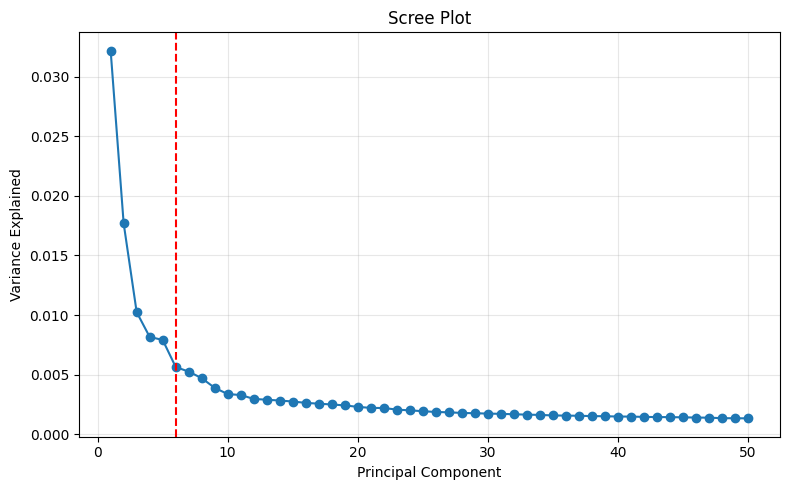

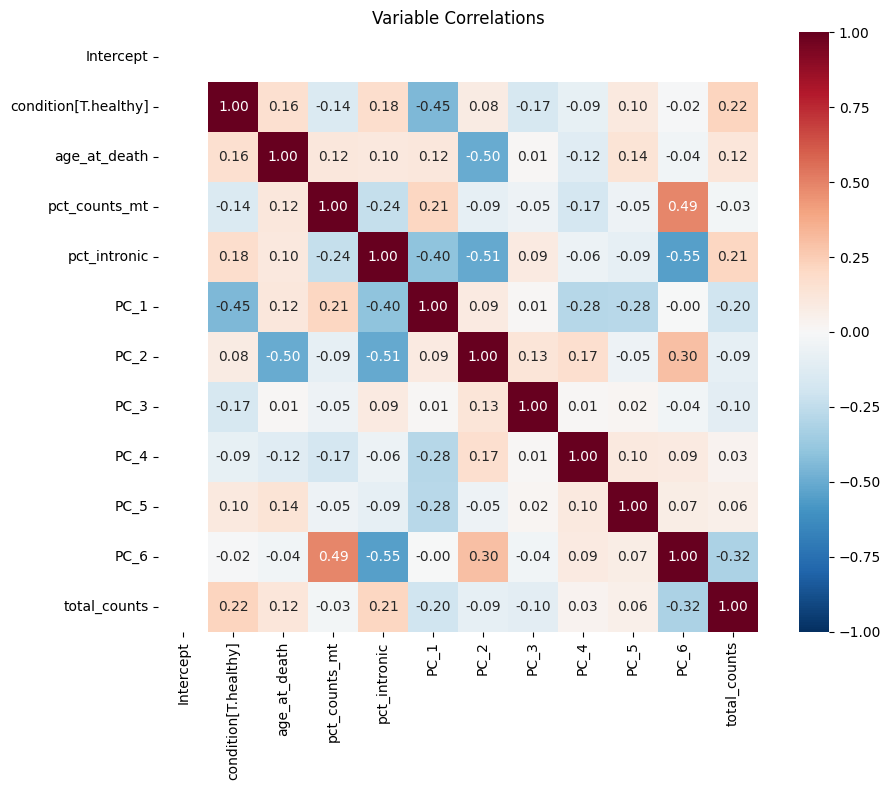

                variable         VIF
0              Intercept  317.512189
4           pct_intronic    2.711080
6                   PC_2    2.697254
10                  PC_6    2.540566
5                   PC_1    2.527349
2           age_at_death    1.900990
1   condition[T.healthy]    1.843545
3          pct_counts_mt    1.708541
11          total_counts    1.325978
8                   PC_4    1.310927
9                   PC_5    1.237331
7                   PC_3    1.216277

binary identifiability test. False


2026-07-24 14:49:19 | [WARNING] R callback write-console: condition: factor | example: diseased
  
2026-07-24 14:49:19 | [WARNING] R callback write-console: donor_id: character | example: SCF-18-003
  
2026-07-24 14:49:19 | [WARNING] R callback write-console: age_at_death: numeric | example: 41
  
2026-07-24 14:49:19 | [WARNING] R callback write-console: pct_counts_mt: numeric | example: 0.0192211586514435
  
2026-07-24 14:49:19 | [WARNING] R callback write-console: pct_intronic: numeric | example: 0.647216633132126
  
2026-07-24 14:49:19 | [WARNING] R callback write-console: PC_1: numeric | example: 13.3974329057549
  
2026-07-24 14:49:19 | [WARNING] R callback write-console: PC_2: numeric | example: 3.96963081406756
  
2026-07-24 14:49:19 | [WARNING] R callback write-console: PC_3: numeric | example: -1.41639403779441
  
2026-07-24 14:49:19 | [WARNING] R callback write-console: PC_4: numeric | example: 4.25931161983091
  
2026-07-24 14:49:19 | [WARNING] R callback write-console: PC_5

factor      beta       se  p_value      fdr
  PC_1  9.679960 3.699848 0.039825 0.238952
  PC_3  2.009419 0.966561 0.082941 0.248823
  PC_2 -2.885886 1.802470 0.160519 0.321038
  PC_6 -1.424969 1.095858 0.241194 0.361791
  PC_4  1.305601 1.296647 0.352815 0.423378
  PC_5 -0.381924 1.382341 0.791607 0.791607
Saving qs file...
	Saving files for R coversion...
	Building R obj...

Setting condition reference level to: healthy
Levels: healthy diseased 
[1] "Creating Seurat object..."


2026-07-24 14:51:24 | [WARNING] R callback write-console: Warning:  
2026-07-24 14:51:24 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


[1] "Saving Seurat object as .qs..."
Running Nebula...
cmd list: ['bash', '/home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh', '--path', '/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/DEG/PCA_nebula/Matrix/tmp_all_lib_adata_zoned_ct-cured_aligned_Matrix_for_nebula.qs', '--id-col', 'donor_id', '--offset-col', 'total_counts', '--n-folds', '40', '--n-cores', '40', '--save-tmp', '0']
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/DEG/PCA_nebula/Matrix/tmp_all_lib_adata_zoned_ct-cured_aligned_Matrix_for_nebula.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/DEG/PCA_nebula/Matrix/tmp_all_lib_adata_zoned_ct-cured_aligned_Matrix_for_nebula.qs --id-col donor_id

... storing 'condition' as categorical
... storing 'ct_for_deg' as categorical
... storing 'ct_for_gradient' as categorical


~ condition + age_at_death + pct_counts_mt + pct_intronic + PC_1 + PC_2 + PC_3 + PC_4 + PC_5 + PC_6 + PC_7 + PC_8 + PC_9 + total_counts


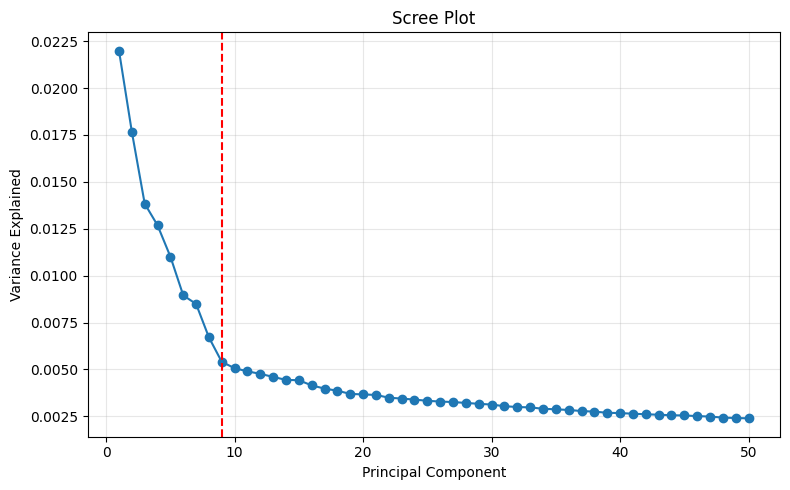

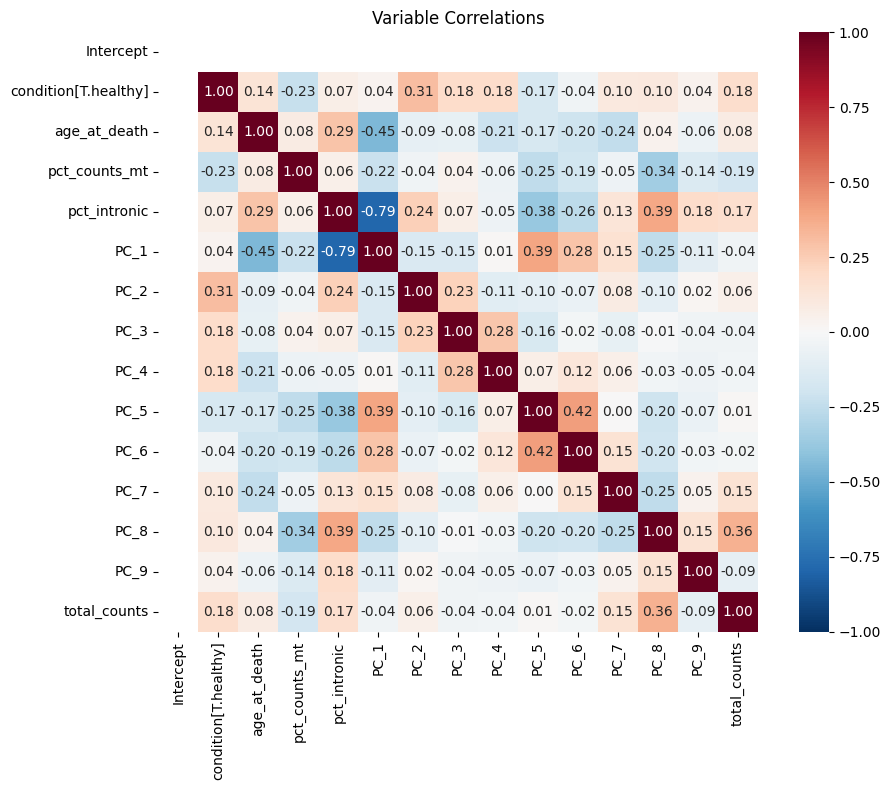

                variable         VIF
0              Intercept  466.199430
4           pct_intronic    4.531422
5                   PC_1    4.375139
12                  PC_8    2.468577
2           age_at_death    1.875730
11                  PC_7    1.806798
3          pct_counts_mt    1.593769
6                   PC_2    1.589752
9                   PC_5    1.586720
1   condition[T.healthy]    1.568464
8                   PC_4    1.364099
14          total_counts    1.358325
10                  PC_6    1.314211
7                   PC_3    1.273131
13                  PC_9    1.126980

binary identifiability test. False


2026-07-24 15:00:30 | [WARNING] R callback write-console: condition: factor | example: diseased
  
2026-07-24 15:00:30 | [WARNING] R callback write-console: donor_id: character | example: SCF-18-003
  
2026-07-24 15:00:30 | [WARNING] R callback write-console: age_at_death: numeric | example: 41
  
2026-07-24 15:00:30 | [WARNING] R callback write-console: pct_counts_mt: numeric | example: 0.0400725524106804
  
2026-07-24 15:00:30 | [WARNING] R callback write-console: pct_intronic: numeric | example: 0.623967897136374
  
2026-07-24 15:00:30 | [WARNING] R callback write-console: PC_1: numeric | example: 2.75462244801021
  
2026-07-24 15:00:30 | [WARNING] R callback write-console: PC_2: numeric | example: -14.7620069450491
  
2026-07-24 15:00:30 | [WARNING] R callback write-console: PC_3: numeric | example: -4.87879903155644
  
2026-07-24 15:00:30 | [WARNING] R callback write-console: PC_4: numeric | example: -2.16165557648479
  
2026-07-24 15:00:30 | [WARNING] R callback write-console: PC

factor      beta       se  p_value      fdr
  PC_2 -5.766920 2.239741 0.042770 0.249015
  PC_3 -1.706426 0.777394 0.071955 0.249015
  PC_4 -2.982555 1.486821 0.092774 0.249015
  PC_5  3.066743 1.677095 0.118125 0.249015
  PC_7 -2.331969 1.365228 0.138342 0.249015
  PC_6  0.424814 0.531261 0.454816 0.622526
  PC_1 -1.244271 1.668356 0.484187 0.622526
  PC_8  0.586349 1.156225 0.630107 0.708870
  PC_9  0.189426 0.559668 0.746628 0.746628
Saving qs file...
	Saving files for R coversion...
	Building R obj...

Setting condition reference level to: healthy
Levels: healthy diseased 
[1] "Creating Seurat object..."


2026-07-24 15:01:07 | [WARNING] R callback write-console: Warning:  
2026-07-24 15:01:07 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


[1] "Saving Seurat object as .qs..."
Running Nebula...
cmd list: ['bash', '/home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh', '--path', '/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/DEG/PCA_nebula/Patch/tmp_all_lib_adata_zoned_ct-cured_aligned_Patch_for_nebula.qs', '--id-col', 'donor_id', '--offset-col', 'total_counts', '--n-folds', '40', '--n-cores', '40', '--save-tmp', '0']
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/DEG/PCA_nebula/Patch/tmp_all_lib_adata_zoned_ct-cured_aligned_Patch_for_nebula.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/DEG/PCA_nebula/Patch/tmp_all_lib_adata_zoned_ct-cured_aligned_Patch_for_nebula.qs --id-col donor_id --off

In [26]:
print("ATTENTION: only 2 donors are 'healthy' in this dataset (SCF-22-057, SCF-23-068) vs "
      "7 'diseased' -> MIN_SAMPLES_PER_CONDITION=4 below means EVERY cell type here will be "
      "skipped for this contrast (healthy n_donors=2 < 4). Lower MIN_SAMPLES_PER_CONDITION in "
      "run_nebula_for_group if you want to force it through anyway - results would be very "
      "fragile with only 2 donors on one side (no real donor-level variance estimate).")

for ct in sorted(adata.obs[CT_FOR_DEG_VARIABLE].unique().tolist()):

    print(f"\n\n######################\n{ct}\n######################\n")

    adata_ct = adata[adata.obs[CT_FOR_DEG_VARIABLE] == ct].copy()

    if TYPE_DEG == "r_nebula":
        adata_ct = adata_ct[adata_ct.obs["r"].notna()].copy()
        print(f"r_nebula mode: {adata_ct.n_obs} cells with valid r remain")

    print(adata_ct.obs.groupby(CONTRAST_VARIABLE)[SAMPLE_VARIABLE].nunique())

    run_nebula_for_group(adata_ct, ct, CONTRAST_VARIABLE, CONTRAST_BASELINE, CONTRAST_STIM, list(COVARIATES_FOR_DEG))

    #break

# Run: cell type vs cell type

Compares any two `ct_for_deg` categories against each other. Optionally restrict to one
condition (`CONDITION_FILTER = "healthy"` or `"diseased"`), or pool both and let `condition`
enter as a covariate (`CONDITION_FILTER = None`).

In [ ]:
CT_BASELINE = "Matrix_D1"
CT_STIM = "Matrix_D2"

# Restrict to one condition before comparing cell types, or None to pool both and add
# `condition` itself as a covariate instead.
#   "healthy"  -> only healthy donors
#   "diseased" -> only diseased donors
#   None       -> keep both, condition becomes a covariate
CONDITION_FILTER = None

adata_ctc = adata[adata.obs[CT_FOR_DEG_VARIABLE].isin([CT_BASELINE, CT_STIM])].copy()

if CONDITION_FILTER is not None:
    adata_ctc = adata_ctc[adata_ctc.obs[CONTRAST_VARIABLE] == CONDITION_FILTER].copy()

if TYPE_DEG == "r_nebula":
    adata_ctc = adata_ctc[adata_ctc.obs["r"].notna()].copy()
    print(f"r_nebula mode: {adata_ctc.n_obs} cells with valid r remain")

print(adata_ctc.obs.groupby([CT_FOR_DEG_VARIABLE, CONTRAST_VARIABLE]).size())

covariates = list(COVARIATES_FOR_DEG)
if CONDITION_FILTER is None:
    covariates.append(CONTRAST_VARIABLE)  # "condition" as covariate since both are pooled

subfolder = f"{CT_BASELINE}_vs_{CT_STIM}" + (f"_{CONDITION_FILTER}" if CONDITION_FILTER else "_allConditions")
run_nebula_for_group(adata_ctc, subfolder, CT_FOR_DEG_VARIABLE, CT_BASELINE, CT_STIM, covariates)